In [1]:
# MODELO 2: CONTROL DE PASAPORTES GENERAL:

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import preprocessing
from matplotlib import pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error
import pandas as pd
import numpy as np
from sklearn import tree

from sklearn.preprocessing import scale
import sklearn
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import r2_score, root_mean_squared_error

In [3]:
df = pd.read_csv("aflu_correct_modelar2.csv")
df

,datetime,active_flt_2h,new_flt_h,real_pax_checkin_adj,tot_pax,real_pax_passport,real_pax_seguridad,new_pax_passport,tot_capacity,tot_capacity_h,...,v_viento,estado_clima,festivo,pax_roll_sec_6h,pax_roll_mean_12h,lag_1,lag_2,lag_3,lag_6,lag_24
0,2025-11-17 04:00:00,9,9.0,355.610000,1590.0,162.375000,749.608333,373.0,1643,1643.0,...,9.7,1.0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,2025-11-17 05:00:00,14,5.0,725.360000,706.0,147.471951,962.428862,0.0,2513,870.0,...,10.4,1.0,0,0.0,0.0,355.610000,NaN,NaN,NaN,NaN
2,2025-11-17 06:00:00,9,4.0,342.240000,709.0,131.853049,979.042886,0.0,1601,731.0,...,10.4,1.0,0,0.0,0.0,725.360000,355.610000,NaN,NaN,NaN
3,2025-11-17 07:00:00,21,17.0,959.440000,3038.0,458.250000,1966.966667,669.0,3997,3266.0,...,10.4,1.0,0,0.0,0.0,342.240000,725.360000,355.610000,NaN,NaN
4,2025-11-17 08:00:00,32,15.0,1817.000000,2819.0,817.154268,2873.841260,1074.0,6196,2930.0,...,10.1,1.0,0,0.0,0.0,959.440000,342.240000,725.360000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,2025-12-07 18:00:00,31,18.0,1555.430000,3401.0,894.370122,2659.526626,746.0,6132,3569.0,...,9.3,2.0,0,1763.0,1100.0,1432.053333,798.580000,723.120000,1100.081667,937.906667
381,2025-12-07 19:00:00,32,14.0,2093.353333,2645.0,850.865854,2980.045935,901.0,6330,2761.0,...,9.3,1.0,0,1988.0,1205.0,1555.430000,1432.053333,798.580000,1067.935000,723.910000
382,2025-12-07 20:00:00,17,3.0,1149.453333,636.0,531.184756,1618.443902,218.0,3419,658.0,...,11.1,1.0,0,2063.0,1132.0,2093.353333,1555.430000,1432.053333,687.470000,310.826667
383,2025-12-07 21:00:00,4,1.0,423.820000,181.0,238.171341,608.111992,181.0,847,189.0,...,11.1,1.0,0,1982.0,1072.0,1149.453333,2093.353333,1555.430000,723.120000,761.776667


In [4]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,375,376,377,378,379,380,381,382,383,384
datetime,2025-11-17 04:00:00,2025-11-17 05:00:00,2025-11-17 06:00:00,2025-11-17 07:00:00,2025-11-17 08:00:00,2025-11-17 09:00:00,2025-11-17 10:00:00,2025-11-17 11:00:00,2025-11-17 12:00:00,2025-11-17 13:00:00,...,2025-12-07 13:00:00,2025-12-07 14:00:00,2025-12-07 15:00:00,2025-12-07 16:00:00,2025-12-07 17:00:00,2025-12-07 18:00:00,2025-12-07 19:00:00,2025-12-07 20:00:00,2025-12-07 21:00:00,2025-12-07 22:00:00
active_flt_2h,9,14,9,21,32,24,18,23,23,14,...,20,13,12,20,26,31,32,17,4,1
new_flt_h,9.0,5.0,4.0,17.0,15.0,9.0,9.0,14.0,9.0,5.0,...,8.0,5.0,7.0,13.0,13.0,18.0,14.0,3.0,1.0,0.0
real_pax_checkin_adj,355.61,725.36,342.24,959.44,1817.0,1501.103333,952.926667,1149.14,1219.08,1006.776667,...,1067.935,687.47,723.12,798.58,1432.053333,1555.43,2093.353333,1149.453333,423.82,50.68
tot_pax,1590.0,706.0,709.0,3038.0,2819.0,1589.0,1602.0,2378.0,1586.0,984.0,...,1457.0,871.0,1243.0,2237.0,2467.0,3401.0,2645.0,636.0,181.0,0.0
real_pax_passport,162.375,147.471951,131.853049,458.25,817.154268,920.967683,619.432927,550.62622,662.285976,483.618293,...,269.935976,313.22561,436.739634,391.89939,767.633537,894.370122,850.865854,531.184756,238.171341,59.07439
real_pax_seguridad,749.608333,962.428862,979.042886,1966.966667,2873.84126,2050.306098,1528.814634,1965.466667,1823.413821,1469.823374,...,1631.914837,1169.496545,1094.45061,1699.583537,2324.939024,2659.526626,2980.045935,1618.443902,608.111992,122.284146
new_pax_passport,373.0,0.0,0.0,669.0,1074.0,698.0,536.0,1033.0,180.0,576.0,...,165.0,351.0,354.0,547.0,1122.0,746.0,901.0,218.0,181.0,0.0
tot_capacity,1643,2513,1601,3997,6196,4573,3360,4230,4172,2680,...,3680,2455,2195,3652,4932,6132,6330,3419,847,189
tot_capacity_h,1643.0,870.0,731.0,3266.0,2930.0,1643.0,1717.0,2513.0,1659.0,1021.0,...,1543.0,912.0,1283.0,2369.0,2563.0,3569.0,2761.0,658.0,189.0,0.0


In [5]:
df = df.drop(columns=['real_pax_seguridad', 'real_pax_checkin_adj', 'pax_momentum_sec',
              'Group_Ryanair_h', 'Group_easy_h', 'Group_wizz_h',
             'OCC_Ryanair', 'OCC_Easy', 'OCC_wizz', 'other_companies','pax_roll_mean_6h',
             'Group_easy', 'Group_wizz', 'festivo', 'pax_momentum', 'Mean_OCC', 'pax_roll_mean_12h'])
# festivo eliminado, no hay datos que caigan en festivo 

In [6]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,375,376,377,378,379,380,381,382,383,384
datetime,2025-11-17 04:00:00,2025-11-17 05:00:00,2025-11-17 06:00:00,2025-11-17 07:00:00,2025-11-17 08:00:00,2025-11-17 09:00:00,2025-11-17 10:00:00,2025-11-17 11:00:00,2025-11-17 12:00:00,2025-11-17 13:00:00,...,2025-12-07 13:00:00,2025-12-07 14:00:00,2025-12-07 15:00:00,2025-12-07 16:00:00,2025-12-07 17:00:00,2025-12-07 18:00:00,2025-12-07 19:00:00,2025-12-07 20:00:00,2025-12-07 21:00:00,2025-12-07 22:00:00
active_flt_2h,9,14,9,21,32,24,18,23,23,14,...,20,13,12,20,26,31,32,17,4,1
new_flt_h,9.0,5.0,4.0,17.0,15.0,9.0,9.0,14.0,9.0,5.0,...,8.0,5.0,7.0,13.0,13.0,18.0,14.0,3.0,1.0,0.0
tot_pax,1590.0,706.0,709.0,3038.0,2819.0,1589.0,1602.0,2378.0,1586.0,984.0,...,1457.0,871.0,1243.0,2237.0,2467.0,3401.0,2645.0,636.0,181.0,0.0
real_pax_passport,162.375,147.471951,131.853049,458.25,817.154268,920.967683,619.432927,550.62622,662.285976,483.618293,...,269.935976,313.22561,436.739634,391.89939,767.633537,894.370122,850.865854,531.184756,238.171341,59.07439
new_pax_passport,373.0,0.0,0.0,669.0,1074.0,698.0,536.0,1033.0,180.0,576.0,...,165.0,351.0,354.0,547.0,1122.0,746.0,901.0,218.0,181.0,0.0
tot_capacity,1643,2513,1601,3997,6196,4573,3360,4230,4172,2680,...,3680,2455,2195,3652,4932,6132,6330,3419,847,189
tot_capacity_h,1643.0,870.0,731.0,3266.0,2930.0,1643.0,1717.0,2513.0,1659.0,1021.0,...,1543.0,912.0,1283.0,2369.0,2563.0,3569.0,2761.0,658.0,189.0,0.0
pax_roll_mean_3h,0.0,0.0,474.0,676.0,1040.0,1426.0,1424.0,1201.0,1107.0,1125.0,...,1062.0,952.0,826.0,736.0,985.0,1262.0,1694.0,1599.0,1222.0,541.0
pax_momentum_pas,0.0,-15.0,-16.0,326.0,359.0,104.0,-302.0,-69.0,112.0,-179.0,...,-237.0,43.0,124.0,-45.0,376.0,127.0,-44.0,-320.0,-293.0,-179.0


In [7]:
# DE MOMENTO NO LO PONGO, AL AÑADIR MÁS DATOS CON FESTIVO LO AÑADO

In [8]:
# tot_pax ES IMPORTANTE PERO CORRELACIONA MUCHO CON NUEVOS VUELOS X HORA 
# pax_roll_mean_3h correlaciona mucho con lag 1h 
df = df.drop(columns=['tot_capacity', 
                      'tot_capacity_h', 'EU_flt_h', 'INT_flt_h', 'NAC_flt_h', 
                      'new_flt_h', 'pax_roll_mean_3h',  'lluvia', 'lag_1', 
                      'lag_2', 'lag_3', 'lag_6', 'lag_24', 'pax_roll_sec_6h'])
# no ha llovido 

In [9]:
df

,datetime,active_flt_2h,tot_pax,real_pax_passport,new_pax_passport,pax_momentum_pas,Group_Ryanair,Ontime_flt,Delayed_flt,EU_flt,INT_flt,NAC_flt,midweek,weekend,v_morning,v_evening,v_night,temperatura,v_viento,estado_clima
0,2025-11-17 04:00:00,9,1590.0,162.375000,373.0,0.0,7,6,3,7,2,0,9,0,9,0,0,10.5,9.7,1.0
1,2025-11-17 05:00:00,14,706.0,147.471951,0.0,-15.0,10,11,3,9,2,3,14,0,14,0,0,10.0,10.4,1.0
2,2025-11-17 06:00:00,9,709.0,131.853049,0.0,-16.0,5,9,0,6,0,3,9,0,9,0,0,9.6,10.4,1.0
3,2025-11-17 07:00:00,21,3038.0,458.250000,669.0,326.0,7,17,4,15,4,2,21,0,21,0,0,9.0,10.4,1.0
4,2025-11-17 08:00:00,32,2819.0,817.154268,1074.0,359.0,12,21,11,20,10,2,32,0,32,0,0,9.9,10.1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,2025-12-07 18:00:00,31,3401.0,894.370122,746.0,127.0,10,23,8,20,10,1,0,31,0,13,18,15.5,9.3,2.0
381,2025-12-07 19:00:00,32,2645.0,850.865854,901.0,-44.0,9,26,6,21,9,2,0,32,0,0,32,14.5,9.3,1.0
382,2025-12-07 20:00:00,17,636.0,531.184756,218.0,-320.0,5,16,1,10,6,1,0,17,0,0,17,13.5,11.1,1.0
383,2025-12-07 21:00:00,4,181.0,238.171341,181.0,-293.0,2,4,0,2,2,0,0,4,0,0,4,13.1,11.1,1.0


In [10]:
df_mod = df.reset_index()

<Axes: >

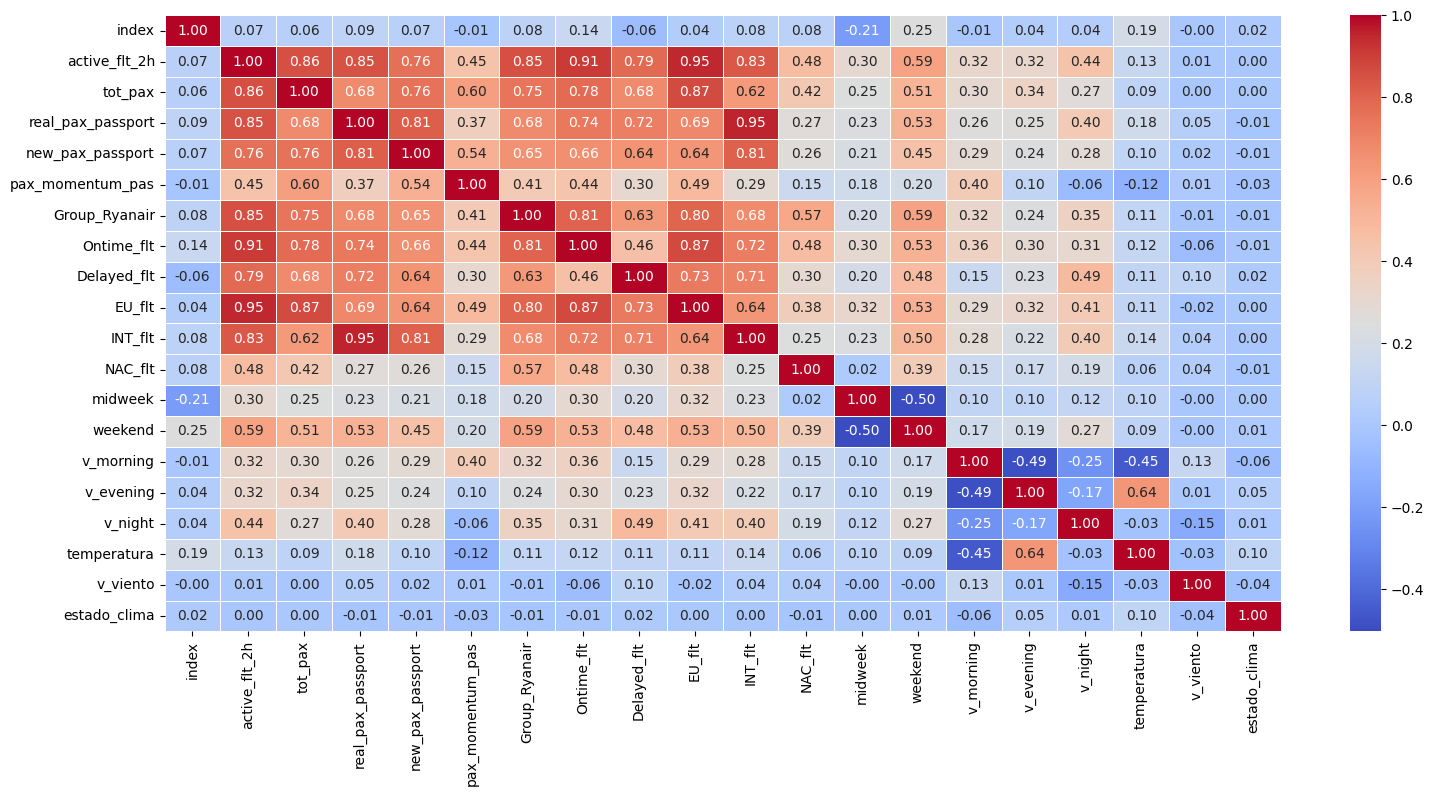

In [11]:
#A = df_mod.groupby("hora")["real_pax_checkin_adj"].sum().reset_index()
B = df_mod.drop(columns=['datetime'])
correlacion = B.corr()
plt.figure(figsize=(18,8))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

In [12]:
# df = df.drop(columns=['festivo', 'real_pax_checkin', 'tot_capacity'])

In [13]:
#A = df_mod.drop(columns=['real_pax_checkin_adj'])

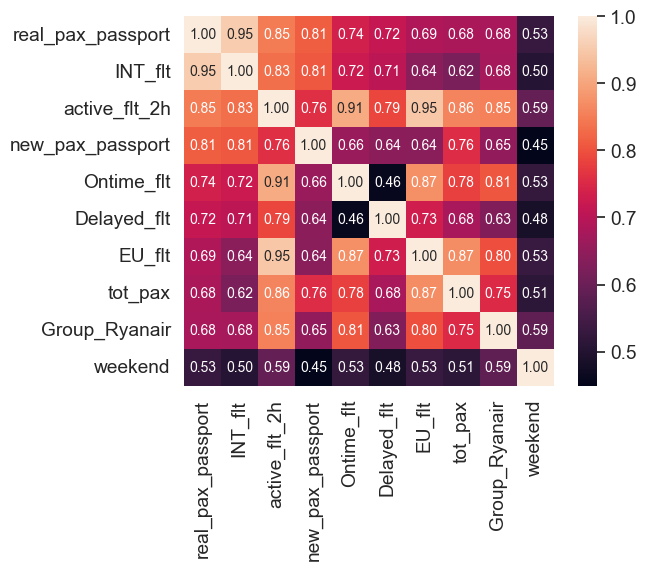

In [14]:
k = 10 #numero de variables
cols = correlacion.nlargest(k, 'real_pax_passport')['real_pax_passport'].index
cm = np.corrcoef(B[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10},
yticklabels=cols.values, xticklabels=cols.values)
plt.show()

In [15]:
df_mod

,index,datetime,active_flt_2h,tot_pax,real_pax_passport,new_pax_passport,pax_momentum_pas,Group_Ryanair,Ontime_flt,Delayed_flt,...,INT_flt,NAC_flt,midweek,weekend,v_morning,v_evening,v_night,temperatura,v_viento,estado_clima
0,0,2025-11-17 04:00:00,9,1590.0,162.375000,373.0,0.0,7,6,3,...,2,0,9,0,9,0,0,10.5,9.7,1.0
1,1,2025-11-17 05:00:00,14,706.0,147.471951,0.0,-15.0,10,11,3,...,2,3,14,0,14,0,0,10.0,10.4,1.0
2,2,2025-11-17 06:00:00,9,709.0,131.853049,0.0,-16.0,5,9,0,...,0,3,9,0,9,0,0,9.6,10.4,1.0
3,3,2025-11-17 07:00:00,21,3038.0,458.250000,669.0,326.0,7,17,4,...,4,2,21,0,21,0,0,9.0,10.4,1.0
4,4,2025-11-17 08:00:00,32,2819.0,817.154268,1074.0,359.0,12,21,11,...,10,2,32,0,32,0,0,9.9,10.1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,380,2025-12-07 18:00:00,31,3401.0,894.370122,746.0,127.0,10,23,8,...,10,1,0,31,0,13,18,15.5,9.3,2.0
381,381,2025-12-07 19:00:00,32,2645.0,850.865854,901.0,-44.0,9,26,6,...,9,2,0,32,0,0,32,14.5,9.3,1.0
382,382,2025-12-07 20:00:00,17,636.0,531.184756,218.0,-320.0,5,16,1,...,6,1,0,17,0,0,17,13.5,11.1,1.0
383,383,2025-12-07 21:00:00,4,181.0,238.171341,181.0,-293.0,2,4,0,...,2,0,0,4,0,0,4,13.1,11.1,1.0


In [16]:
df_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385 entries, 0 to 384
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              385 non-null    int64  
 1   datetime           385 non-null    object 
 2   active_flt_2h      385 non-null    int64  
 3   tot_pax            385 non-null    float64
 4   real_pax_passport  385 non-null    float64
 5   new_pax_passport   385 non-null    float64
 6   pax_momentum_pas   385 non-null    float64
 7   Group_Ryanair      385 non-null    int64  
 8   Ontime_flt         385 non-null    int64  
 9   Delayed_flt        385 non-null    int64  
 10  EU_flt             385 non-null    int64  
 11  INT_flt            385 non-null    int64  
 12  NAC_flt            385 non-null    int64  
 13  midweek            385 non-null    int64  
 14  weekend            385 non-null    int64  
 15  v_morning          385 non-null    int64  
 16  v_evening          385 non

In [17]:
df_mod['datetime']= pd.to_datetime(df_mod["datetime"])

In [18]:
df_mod["hora"] = df_mod["datetime"].dt.hour
df_mod["fecha"] = df_mod["datetime"].dt.date


In [19]:
df_mod

,index,datetime,active_flt_2h,tot_pax,real_pax_passport,new_pax_passport,pax_momentum_pas,Group_Ryanair,Ontime_flt,Delayed_flt,...,midweek,weekend,v_morning,v_evening,v_night,temperatura,v_viento,estado_clima,hora,fecha
0,0,2025-11-17 04:00:00,9,1590.0,162.375000,373.0,0.0,7,6,3,...,9,0,9,0,0,10.5,9.7,1.0,4,2025-11-17
1,1,2025-11-17 05:00:00,14,706.0,147.471951,0.0,-15.0,10,11,3,...,14,0,14,0,0,10.0,10.4,1.0,5,2025-11-17
2,2,2025-11-17 06:00:00,9,709.0,131.853049,0.0,-16.0,5,9,0,...,9,0,9,0,0,9.6,10.4,1.0,6,2025-11-17
3,3,2025-11-17 07:00:00,21,3038.0,458.250000,669.0,326.0,7,17,4,...,21,0,21,0,0,9.0,10.4,1.0,7,2025-11-17
4,4,2025-11-17 08:00:00,32,2819.0,817.154268,1074.0,359.0,12,21,11,...,32,0,32,0,0,9.9,10.1,1.0,8,2025-11-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,380,2025-12-07 18:00:00,31,3401.0,894.370122,746.0,127.0,10,23,8,...,0,31,0,13,18,15.5,9.3,2.0,18,2025-12-07
381,381,2025-12-07 19:00:00,32,2645.0,850.865854,901.0,-44.0,9,26,6,...,0,32,0,0,32,14.5,9.3,1.0,19,2025-12-07
382,382,2025-12-07 20:00:00,17,636.0,531.184756,218.0,-320.0,5,16,1,...,0,17,0,0,17,13.5,11.1,1.0,20,2025-12-07
383,383,2025-12-07 21:00:00,4,181.0,238.171341,181.0,-293.0,2,4,0,...,0,4,0,0,4,13.1,11.1,1.0,21,2025-12-07


In [20]:
df_mod[(df_mod['datetime'] == '2025-11-30 04:00:00')]

,index,datetime,active_flt_2h,tot_pax,real_pax_passport,new_pax_passport,pax_momentum_pas,Group_Ryanair,Ontime_flt,Delayed_flt,...,midweek,weekend,v_morning,v_evening,v_night,temperatura,v_viento,estado_clima,hora,fecha
237,237,2025-11-30 04:00:00,7,1237.0,135.65,174.0,33.0,6,7,0,...,0,7,7,0,0,8.0,9.0,2.0,4,2025-11-30


In [21]:
# OBSERVACION EL LAG NO ES 0 , NORMALMENTE Y POR LOGICA A LAS 3 DE LA MAÑANA NO HAY 
# AFLUENCIA Y MOVIMIENTO EL COGE LO QUE HA PASADO A LAS 22 

In [22]:
#df_mod = df_mod.drop(columns=['lag_1', 'lag_2', 'lag_3', 'lag_6','lag_24'])

## MODELO

In [23]:
df_mod.isna().sum()

index                0
datetime             0
active_flt_2h        0
tot_pax              0
real_pax_passport    0
new_pax_passport     0
pax_momentum_pas     0
Group_Ryanair        0
Ontime_flt           0
Delayed_flt          0
EU_flt               0
INT_flt              0
NAC_flt              0
midweek              0
weekend              0
v_morning            0
v_evening            0
v_night              0
temperatura          0
v_viento             0
estado_clima         0
hora                 0
fecha                0
dtype: int64

In [24]:
df_mod.T

,0,1,2,3,4,5,6,7,8,9,...,375,376,377,378,379,380,381,382,383,384
index,0,1,2,3,4,5,6,7,8,9,...,375,376,377,378,379,380,381,382,383,384
datetime,2025-11-17 04:00:00,2025-11-17 05:00:00,2025-11-17 06:00:00,2025-11-17 07:00:00,2025-11-17 08:00:00,2025-11-17 09:00:00,2025-11-17 10:00:00,2025-11-17 11:00:00,2025-11-17 12:00:00,2025-11-17 13:00:00,...,2025-12-07 13:00:00,2025-12-07 14:00:00,2025-12-07 15:00:00,2025-12-07 16:00:00,2025-12-07 17:00:00,2025-12-07 18:00:00,2025-12-07 19:00:00,2025-12-07 20:00:00,2025-12-07 21:00:00,2025-12-07 22:00:00
active_flt_2h,9,14,9,21,32,24,18,23,23,14,...,20,13,12,20,26,31,32,17,4,1
tot_pax,1590.0,706.0,709.0,3038.0,2819.0,1589.0,1602.0,2378.0,1586.0,984.0,...,1457.0,871.0,1243.0,2237.0,2467.0,3401.0,2645.0,636.0,181.0,0.0
real_pax_passport,162.375,147.471951,131.853049,458.25,817.154268,920.967683,619.432927,550.62622,662.285976,483.618293,...,269.935976,313.22561,436.739634,391.89939,767.633537,894.370122,850.865854,531.184756,238.171341,59.07439
new_pax_passport,373.0,0.0,0.0,669.0,1074.0,698.0,536.0,1033.0,180.0,576.0,...,165.0,351.0,354.0,547.0,1122.0,746.0,901.0,218.0,181.0,0.0
pax_momentum_pas,0.0,-15.0,-16.0,326.0,359.0,104.0,-302.0,-69.0,112.0,-179.0,...,-237.0,43.0,124.0,-45.0,376.0,127.0,-44.0,-320.0,-293.0,-179.0
Group_Ryanair,7,10,5,7,12,11,8,9,6,3,...,8,8,9,10,10,10,9,5,2,1
Ontime_flt,6,11,9,17,21,16,14,14,12,8,...,20,13,11,17,21,23,26,16,4,1
Delayed_flt,3,3,0,4,11,8,4,9,11,6,...,0,0,1,3,5,8,6,1,0,0


In [25]:
import skforecast
print(skforecast.__version__)

0.14.0


In [26]:
# Data manipulation
# ==============================================================================
import numpy as np
import pandas as pd
from skforecast.datasets import fetch_dataset

# Plots # resetear graficos 
# ==============================================================================
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 10

# Modeling and Forecasting
# ==============================================================================
import sklearn
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import skforecast
from skforecast.recursive import ForecasterRecursive
from skforecast.direct import ForecasterDirect
from skforecast.model_selection import TimeSeriesFold
from skforecast.model_selection import grid_search_forecaster
from skforecast.model_selection import backtesting_forecaster
# pre procesador 
from skforecast.preprocessing import RollingFeatures
from skforecast.utils import save_forecaster
from skforecast.utils import load_forecaster
import shap


import warnings
warnings.filterwarnings('once')
warnings.filterwarnings("ignore", category=DeprecationWarning)

color = '\033[1m\033[38;5;208m' 
print(f"{color}Version skforecast: {skforecast.__version__}")
print(f"{color}Version scikit-learn: {sklearn.__version__}")
print(f"{color}Version pandas: {pd.__version__}")
print(f"{color}Version numpy: {np.__version__}")

C:\Users\linap\anaconda3\envs\skf_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Version skforecast: 0.14.0
Version scikit-learn: 1.7.2
Version pandas: 2.3.3
Version numpy: 2.2.6


In [27]:
# si tiene estas fechas es finde semana
"""
weekend_days = [
    pd.to_datetime("2025-11-21").date(),
    pd.to_datetime("2025-11-22").date(),
    pd.to_datetime("2025-11-23").date(),
    pd.to_datetime("2025-11-28").date(),
    pd.to_datetime("2025-11-29").date(),
    pd.to_datetime("2025-11-30").date(),
]

df_mod["is_weekend"] = df_mod["fecha"].isin(weekend_days).astype(int)

df_mod["is_midweek"] = (df_mod["is_weekend"] == 0).astype(int)
"""

# Si la variable ontime es diferente a 0 indicar 1 
#df_mod["is_Ontime"] = (df_mod["Ontime_flt"] != 0).astype(int)
# Si la variable delay es diferente a 0 indicar 1 
#df_mod["is_Delayed"] = (df_mod["Delayed_flt"] != 0).astype(int)
#df_mod["is_midweek"] = (df_mod["is_weekend"] == 0).astype(int)
#df_mod['fecha'] = pd.to_datetime(df_mod['fecha'], errors="coerce")
#df_mod["weekday"] = df_mod["fecha"].dt.weekday  # 0–6
#df_mod["is_weekend"] = df_mod["weekday"].isin([4, 6]).astype(int)

#df_mod["is_morning"] = df_mod["hora"].between(4,11).astype(int)
#df_mod["is_evening"] = df_mod["hora"].between(12,18).astype(int)
#df_mod["is_night"] = (df_mod["hora"].between(19, 23) | df_mod["hora"].between(0, 3)).astype(int)
# ONTIME Y DELAY 
#df_mod = df_mod.drop(columns=['weekend', 'midweek', 'v_morning', 'v_evening', 'v_night'])

'\nweekend_days = [\n    pd.to_datetime("2025-11-21").date(),\n    pd.to_datetime("2025-11-22").date(),\n    pd.to_datetime("2025-11-23").date(),\n    pd.to_datetime("2025-11-28").date(),\n    pd.to_datetime("2025-11-29").date(),\n    pd.to_datetime("2025-11-30").date(),\n]\n\ndf_mod["is_weekend"] = df_mod["fecha"].isin(weekend_days).astype(int)\n\ndf_mod["is_midweek"] = (df_mod["is_weekend"] == 0).astype(int)\n'

In [28]:
df_mod

,index,datetime,active_flt_2h,tot_pax,real_pax_passport,new_pax_passport,pax_momentum_pas,Group_Ryanair,Ontime_flt,Delayed_flt,...,midweek,weekend,v_morning,v_evening,v_night,temperatura,v_viento,estado_clima,hora,fecha
0,0,2025-11-17 04:00:00,9,1590.0,162.375000,373.0,0.0,7,6,3,...,9,0,9,0,0,10.5,9.7,1.0,4,2025-11-17
1,1,2025-11-17 05:00:00,14,706.0,147.471951,0.0,-15.0,10,11,3,...,14,0,14,0,0,10.0,10.4,1.0,5,2025-11-17
2,2,2025-11-17 06:00:00,9,709.0,131.853049,0.0,-16.0,5,9,0,...,9,0,9,0,0,9.6,10.4,1.0,6,2025-11-17
3,3,2025-11-17 07:00:00,21,3038.0,458.250000,669.0,326.0,7,17,4,...,21,0,21,0,0,9.0,10.4,1.0,7,2025-11-17
4,4,2025-11-17 08:00:00,32,2819.0,817.154268,1074.0,359.0,12,21,11,...,32,0,32,0,0,9.9,10.1,1.0,8,2025-11-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,380,2025-12-07 18:00:00,31,3401.0,894.370122,746.0,127.0,10,23,8,...,0,31,0,13,18,15.5,9.3,2.0,18,2025-12-07
381,381,2025-12-07 19:00:00,32,2645.0,850.865854,901.0,-44.0,9,26,6,...,0,32,0,0,32,14.5,9.3,1.0,19,2025-12-07
382,382,2025-12-07 20:00:00,17,636.0,531.184756,218.0,-320.0,5,16,1,...,0,17,0,0,17,13.5,11.1,1.0,20,2025-12-07
383,383,2025-12-07 21:00:00,4,181.0,238.171341,181.0,-293.0,2,4,0,...,0,4,0,0,4,13.1,11.1,1.0,21,2025-12-07


In [29]:
df_mod = df_mod.set_index("datetime")
#df_mod = df_mod.drop(columns=['hora', 'fecha'])
df_mod = df_mod.asfreq("h")
num_cols = [
    'real_pax_passport', 'active_flt_2h', 'tot_pax','pax_momentum_pas',
    'EU_flt', 'INT_flt', 'NAC_flt', 'Delayed_flt',
    'Ontime_flt', 'Group_Ryanair','new_pax_passport'
]

df_mod[num_cols] = df_mod[num_cols].fillna(0)

df_mod = df_mod.sort_index()
df_mod

,index,active_flt_2h,tot_pax,real_pax_passport,new_pax_passport,pax_momentum_pas,Group_Ryanair,Ontime_flt,Delayed_flt,EU_flt,...,midweek,weekend,v_morning,v_evening,v_night,temperatura,v_viento,estado_clima,hora,fecha
datetime,,,,,,,,,,,,,,,,,,,,,
2025-11-17 04:00:00,0.0,9.0,1590.0,162.375000,373.0,0.0,7.0,6.0,3.0,7.0,...,9.0,0.0,9.0,0.0,0.0,10.5,9.7,1.0,4.0,2025-11-17
2025-11-17 05:00:00,1.0,14.0,706.0,147.471951,0.0,-15.0,10.0,11.0,3.0,9.0,...,14.0,0.0,14.0,0.0,0.0,10.0,10.4,1.0,5.0,2025-11-17
2025-11-17 06:00:00,2.0,9.0,709.0,131.853049,0.0,-16.0,5.0,9.0,0.0,6.0,...,9.0,0.0,9.0,0.0,0.0,9.6,10.4,1.0,6.0,2025-11-17
2025-11-17 07:00:00,3.0,21.0,3038.0,458.250000,669.0,326.0,7.0,17.0,4.0,15.0,...,21.0,0.0,21.0,0.0,0.0,9.0,10.4,1.0,7.0,2025-11-17
2025-11-17 08:00:00,4.0,32.0,2819.0,817.154268,1074.0,359.0,12.0,21.0,11.0,20.0,...,32.0,0.0,32.0,0.0,0.0,9.9,10.1,1.0,8.0,2025-11-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-07 18:00:00,380.0,31.0,3401.0,894.370122,746.0,127.0,10.0,23.0,8.0,20.0,...,0.0,31.0,0.0,13.0,18.0,15.5,9.3,2.0,18.0,2025-12-07
2025-12-07 19:00:00,381.0,32.0,2645.0,850.865854,901.0,-44.0,9.0,26.0,6.0,21.0,...,0.0,32.0,0.0,0.0,32.0,14.5,9.3,1.0,19.0,2025-12-07
2025-12-07 20:00:00,382.0,17.0,636.0,531.184756,218.0,-320.0,5.0,16.0,1.0,10.0,...,0.0,17.0,0.0,0.0,17.0,13.5,11.1,1.0,20.0,2025-12-07


In [30]:
clima_cols = ['v_viento', 'estado_clima', 'temperatura']
df_mod[clima_cols] = df_mod[clima_cols].ffill()

In [31]:
df_mod.head(30)

,index,active_flt_2h,tot_pax,real_pax_passport,new_pax_passport,pax_momentum_pas,Group_Ryanair,Ontime_flt,Delayed_flt,EU_flt,...,midweek,weekend,v_morning,v_evening,v_night,temperatura,v_viento,estado_clima,hora,fecha
datetime,,,,,,,,,,,,,,,,,,,,,
2025-11-17 04:00:00,0.0,9.0,1590.0,162.375000,373.0,0.0,7.0,6.0,3.0,7.0,...,9.0,0.0,9.0,0.0,0.0,10.5,9.7,1.0,4.0,2025-11-17
2025-11-17 05:00:00,1.0,14.0,706.0,147.471951,0.0,-15.0,10.0,11.0,3.0,9.0,...,14.0,0.0,14.0,0.0,0.0,10.0,10.4,1.0,5.0,2025-11-17
2025-11-17 06:00:00,2.0,9.0,709.0,131.853049,0.0,-16.0,5.0,9.0,0.0,6.0,...,9.0,0.0,9.0,0.0,0.0,9.6,10.4,1.0,6.0,2025-11-17
2025-11-17 07:00:00,3.0,21.0,3038.0,458.250000,669.0,326.0,7.0,17.0,4.0,15.0,...,21.0,0.0,21.0,0.0,0.0,9.0,10.4,1.0,7.0,2025-11-17
2025-11-17 08:00:00,4.0,32.0,2819.0,817.154268,1074.0,359.0,12.0,21.0,11.0,20.0,...,32.0,0.0,32.0,0.0,0.0,9.9,10.1,1.0,8.0,2025-11-17
2025-11-17 09:00:00,5.0,24.0,1589.0,920.967683,698.0,104.0,11.0,16.0,8.0,14.0,...,24.0,0.0,24.0,0.0,0.0,12.5,7.6,1.0,9.0,2025-11-17
2025-11-17 10:00:00,6.0,18.0,1602.0,619.432927,536.0,-302.0,8.0,14.0,4.0,10.0,...,18.0,0.0,9.0,9.0,0.0,15.1,6.1,1.0,10.0,2025-11-17
2025-11-17 11:00:00,7.0,23.0,2378.0,550.626220,1033.0,-69.0,9.0,14.0,9.0,13.0,...,23.0,0.0,0.0,23.0,0.0,16.6,6.8,3.0,11.0,2025-11-17
2025-11-17 12:00:00,8.0,23.0,1586.0,662.285976,180.0,112.0,6.0,12.0,11.0,15.0,...,23.0,0.0,0.0,23.0,0.0,17.2,7.6,3.0,12.0,2025-11-17


In [32]:
#df_mod['Mean_OCC'] = df_mod['Mean_OCC'].fillna(0) # PUNTUAL, SOLO PORQUE LA NECESITO
# NO HAY VUELOS CUANDO NO HAY OCUPACIÓN FACILITAR EL ENTENDIMIENTO AL MODELO
# CREANDO UNA VARIABLE QUE LE INDIQUE QUE ES 0 PORQUE NO HAY VUELO. 
df_mod["no_vuelos"] = (df_mod["active_flt_2h"] == 0).astype(int)


In [33]:
# 
df_mod['fecha'] = pd.to_datetime(df_mod['fecha'], errors="coerce")
#df_mod["weekday"] = df_mod["fecha"].dt.weekday  # 0–6
#df_mod["is_weekend"] = df_mod["weekday"].isin([4, 6]).astype(int)
df_mod["weekday_num"] = df_mod.index.weekday      # 0–6
df_mod["is_weekend"] = df_mod["weekday_num"].isin([5,6]).astype(int)
df_mod["is_weekday"] = (df_mod["is_weekend"] == 0).astype(int)

# DUMMIES TEMPORALES 
df_mod["h"] = df_mod.index.hour

df_mod["is_morning"] = df_mod["h"].between(4,11).astype(int)
df_mod["is_evening"] = df_mod["h"].between(12,19).astype(int)
df_mod["is_night"] = (
    (df_mod["h"] >= 20) | (df_mod["h"] <= 3)
).astype(int)

# ONTIME Y DELAY 
df_mod = df_mod.drop(columns=['weekend', 'midweek', 'v_morning', 'v_evening', 'v_night', 'h'])

In [34]:
df_mod["index"] = np.arange(len(df_mod)) # reestablecer indice correcto 

In [35]:
df_fest = pd.read_csv("festividades_bcn.csv")
df_fest["Date_holiday"] = pd.to_datetime(df_fest["Date_holiday"]).dt.date
df_mod["festivo"] = df_mod["fecha"].isin(df_fest["Date_holiday"]).astype(int)
df_mod["Visp_fest"] = df_mod["fecha"].isin(df_fest["holiday_eve"]).astype(int)
# devuelve True si la fecha está en la tabla de festivos. 

C:\Users\linap\AppData\Local\Temp\ipykernel_19156\3300672883.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_mod["festivo"] = df_mod["fecha"].isin(df_fest["Date_holiday"]).astype(int)
C:\Users\linap\AppData\Local\Temp\ipykernel_19156\3300672883.py:4: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_mod["Visp_fest"] = df_mod["fecha"].isin(df_fest["holiday_eve"]).astype(int)


In [36]:
df_mod = df_mod.drop(columns=['fecha', 'hora'])

In [37]:
df_mod.isna().sum()

index                0
active_flt_2h        0
tot_pax              0
real_pax_passport    0
new_pax_passport     0
pax_momentum_pas     0
Group_Ryanair        0
Ontime_flt           0
Delayed_flt          0
EU_flt               0
INT_flt              0
NAC_flt              0
temperatura          0
v_viento             0
estado_clima         0
no_vuelos            0
weekday_num          0
is_weekend           0
is_weekday           0
is_morning           0
is_evening           0
is_night             0
festivo              0
Visp_fest            0
dtype: int64

In [38]:
df_mod.head().T

datetime,2025-11-17 04:00:00,2025-11-17 05:00:00,2025-11-17 06:00:00,2025-11-17 07:00:00,2025-11-17 08:00:00
index,0.000,1.000000,2.000000,3.00,4.000000
active_flt_2h,9.000,14.000000,9.000000,21.00,32.000000
tot_pax,1590.000,706.000000,709.000000,3038.00,2819.000000
real_pax_passport,162.375,147.471951,131.853049,458.25,817.154268
new_pax_passport,373.000,0.000000,0.000000,669.00,1074.000000
pax_momentum_pas,0.000,-15.000000,-16.000000,326.00,359.000000
Group_Ryanair,7.000,10.000000,5.000000,7.00,12.000000
Ontime_flt,6.000,11.000000,9.000000,17.00,21.000000
Delayed_flt,3.000,3.000000,0.000000,4.00,11.000000
EU_flt,7.000,9.000000,6.000000,15.00,20.000000


In [39]:
df_mod.to_csv("Tabla_modelo_pasaporte.csv")

In [40]:
#a las 3 ninguna hora la manana de 4 a 11, tarde de 12 a 18 y noche 7 a 22

<Axes: >

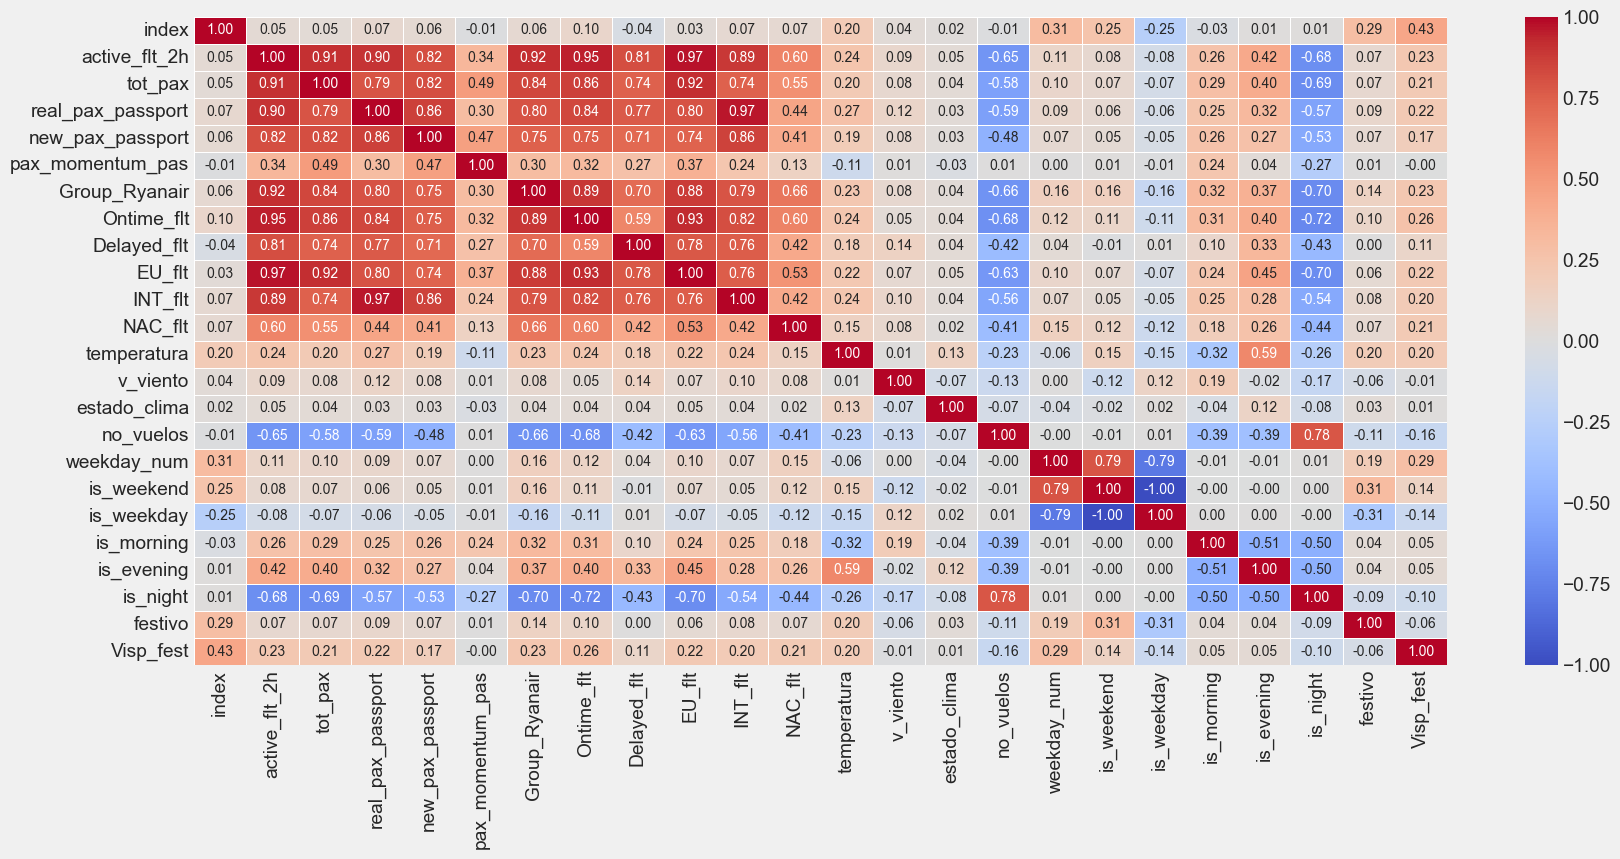

In [41]:
### B = df_mod.drop(columns=['datetime'])
correlacion = df_mod.corr()
plt.figure(figsize=(18,8))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

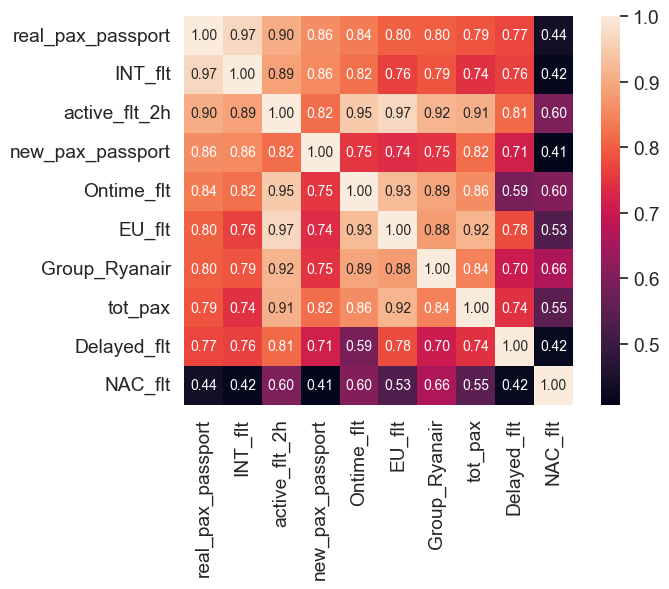

In [42]:
k = 10 #numero de variables
cols = correlacion.nlargest(k, 'real_pax_passport')['real_pax_passport'].index
cm = np.corrcoef(df_mod[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10},
yticklabels=cols.values, xticklabels=cols.values)
plt.show()

In [43]:
# AÑADIR ONTIME Y DELAY COMO BINARIO
# RELLENAR NANS SEGUN TIPO DE VARIABLE O POR VAR PREVIA O POR 0 

In [44]:
print(f'Número de filas con missing values: {df_mod.isnull().any(axis=1).mean()}')

Número de filas con missing values: 0.0


In [45]:
df_mod.T

datetime,2025-11-17 04:00:00,2025-11-17 05:00:00,2025-11-17 06:00:00,2025-11-17 07:00:00,2025-11-17 08:00:00,2025-11-17 09:00:00,2025-11-17 10:00:00,2025-11-17 11:00:00,2025-11-17 12:00:00,2025-11-17 13:00:00,...,2025-12-07 13:00:00,2025-12-07 14:00:00,2025-12-07 15:00:00,2025-12-07 16:00:00,2025-12-07 17:00:00,2025-12-07 18:00:00,2025-12-07 19:00:00,2025-12-07 20:00:00,2025-12-07 21:00:00,2025-12-07 22:00:00
index,0.000,1.000000,2.000000,3.00,4.000000,5.000000,6.000000,7.00000,8.000000,9.000000,...,489.000000,490.00000,491.000000,492.00000,493.000000,494.000000,495.000000,496.000000,497.000000,498.00000
active_flt_2h,9.000,14.000000,9.000000,21.00,32.000000,24.000000,18.000000,23.00000,23.000000,14.000000,...,20.000000,13.00000,12.000000,20.00000,26.000000,31.000000,32.000000,17.000000,4.000000,1.00000
tot_pax,1590.000,706.000000,709.000000,3038.00,2819.000000,1589.000000,1602.000000,2378.00000,1586.000000,984.000000,...,1457.000000,871.00000,1243.000000,2237.00000,2467.000000,3401.000000,2645.000000,636.000000,181.000000,0.00000
real_pax_passport,162.375,147.471951,131.853049,458.25,817.154268,920.967683,619.432927,550.62622,662.285976,483.618293,...,269.935976,313.22561,436.739634,391.89939,767.633537,894.370122,850.865854,531.184756,238.171341,59.07439
new_pax_passport,373.000,0.000000,0.000000,669.00,1074.000000,698.000000,536.000000,1033.00000,180.000000,576.000000,...,165.000000,351.00000,354.000000,547.00000,1122.000000,746.000000,901.000000,218.000000,181.000000,0.00000
pax_momentum_pas,0.000,-15.000000,-16.000000,326.00,359.000000,104.000000,-302.000000,-69.00000,112.000000,-179.000000,...,-237.000000,43.00000,124.000000,-45.00000,376.000000,127.000000,-44.000000,-320.000000,-293.000000,-179.00000
Group_Ryanair,7.000,10.000000,5.000000,7.00,12.000000,11.000000,8.000000,9.00000,6.000000,3.000000,...,8.000000,8.00000,9.000000,10.00000,10.000000,10.000000,9.000000,5.000000,2.000000,1.00000
Ontime_flt,6.000,11.000000,9.000000,17.00,21.000000,16.000000,14.000000,14.00000,12.000000,8.000000,...,20.000000,13.00000,11.000000,17.00000,21.000000,23.000000,26.000000,16.000000,4.000000,1.00000
Delayed_flt,3.000,3.000000,0.000000,4.00,11.000000,8.000000,4.000000,9.00000,11.000000,6.000000,...,0.000000,0.00000,1.000000,3.00000,5.000000,8.000000,6.000000,1.000000,0.000000,0.00000
EU_flt,7.000,9.000000,6.000000,15.00,20.000000,14.000000,10.000000,13.00000,15.000000,9.000000,...,15.000000,10.00000,7.000000,12.00000,15.000000,20.000000,21.000000,10.000000,2.000000,0.00000


In [46]:
# df['OCC'] = df['OCC'].fillna(0)
# df["no_vuelos"] = (df["new_flt_h"] == 0).astype(int)

In [47]:
# PROBAR CON XGBOOST QUE MANEJA NANS, DEPENDE METRICA VOLVER A GESTIONAR NANS 

In [48]:
(df_mod.index == pd.date_range(
                    start = df_mod.index.min(),
                    end   = df_mod.index.max(),
                    freq  = df_mod.index.freq)
).all()

np.True_

Fechas train : 2025-11-17 04:00:00 --- 2025-12-06 08:00:00  (n=461)
Fechas test  : 2025-12-06 09:00:00 --- 2025-12-07 22:00:00  (n=38)


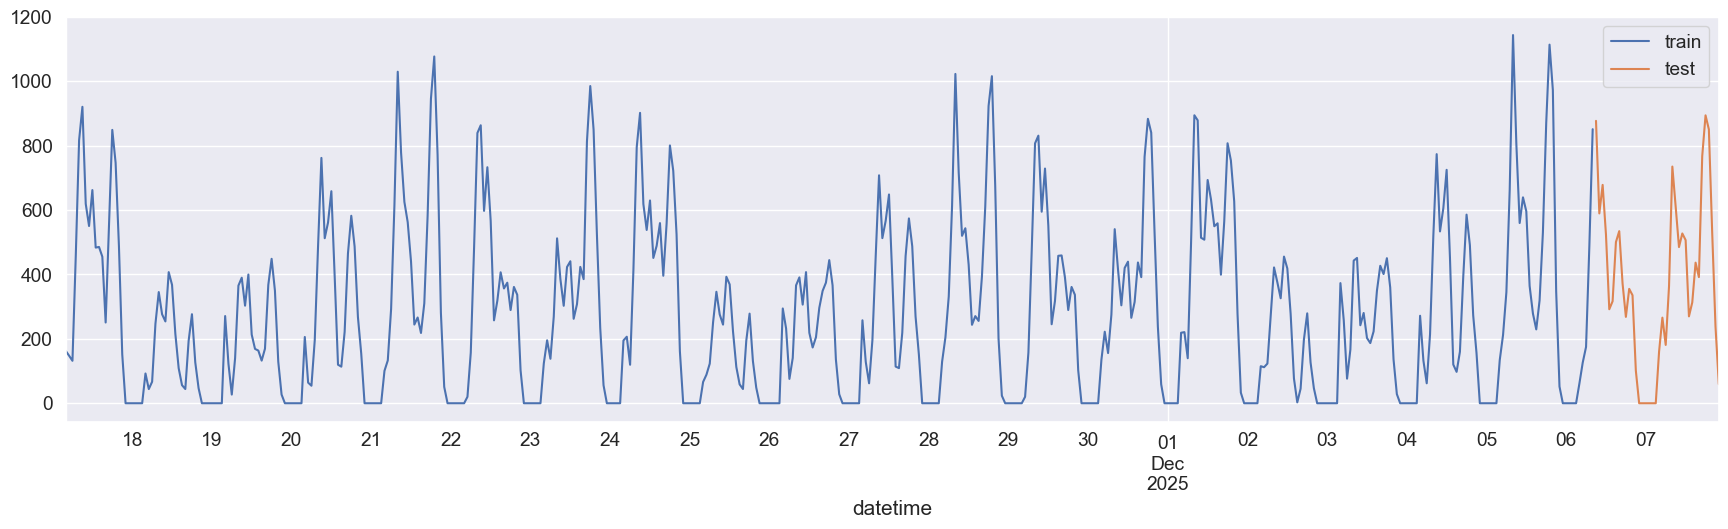

In [49]:
# Separación datos train-test
# ==============================================================================
steps = 38
datos_train = df_mod[:-steps] # desde el inicio hasta 36 pasos anteriores
datos_test  = df_mod[-steps:] # 

print(f"Fechas train : {datos_train.index.min()} --- {datos_train.index.max()}  (n={len(datos_train)})")
print(f"Fechas test  : {datos_test.index.min()} --- {datos_test.index.max()}  (n={len(datos_test)})")

fig, ax = plt.subplots(figsize=(19, 5))
datos_train['real_pax_passport'].plot(ax=ax, label='train')
datos_test['real_pax_passport'].plot(ax=ax, label='test')
ax.legend();

<Axes: xlabel='datetime'>

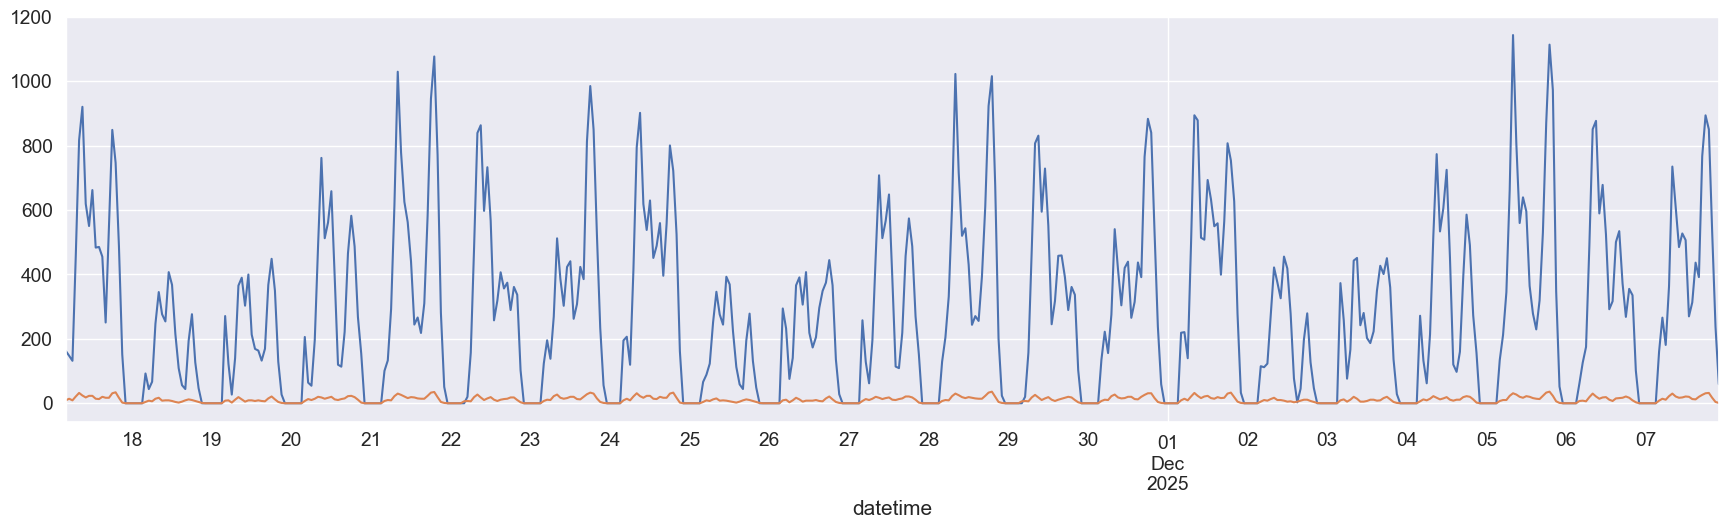

In [50]:
fig, ax = plt.subplots(figsize=(19, 5))
df_mod['real_pax_passport'].plot(ax=ax, label='y')
df_mod['active_flt_2h'].plot(ax=ax, label='variable exógena')

<Axes: xlabel='datetime'>

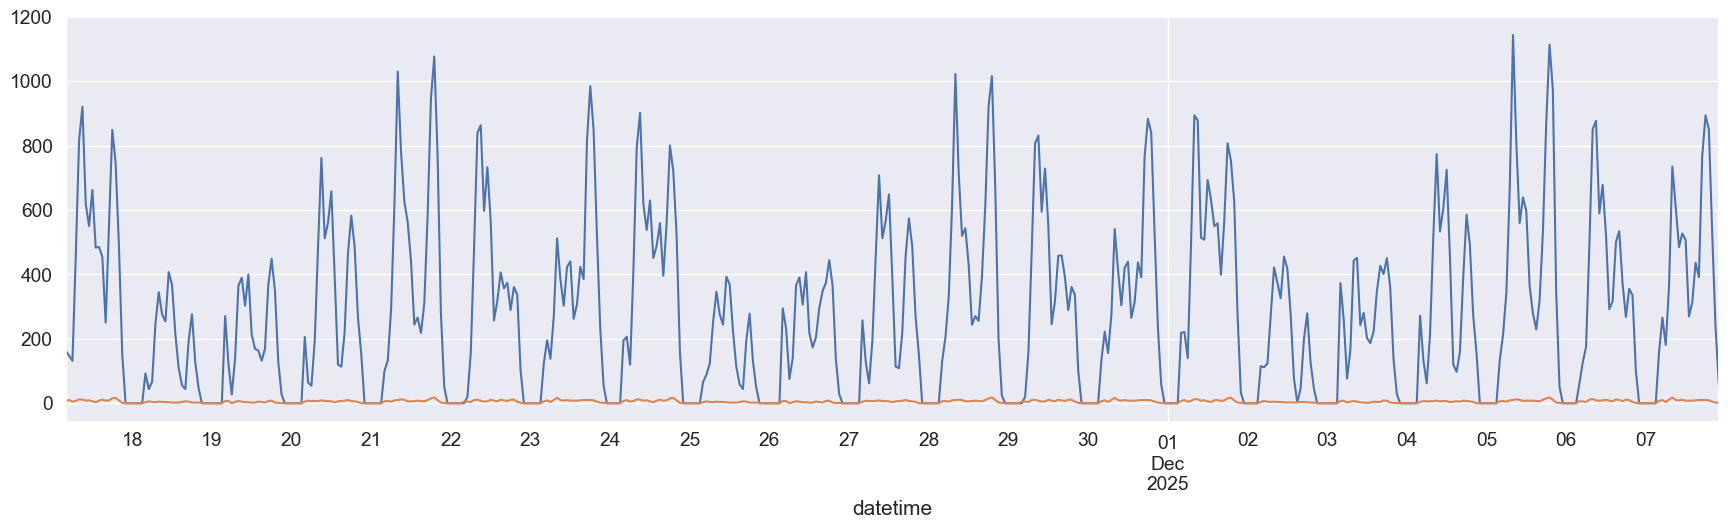

In [51]:
fig, ax = plt.subplots(figsize=(19, 5))
df_mod['real_pax_passport'].plot(ax=ax, label='y')
df_mod['Group_Ryanair'].plot(ax=ax, label='variable exógena')

<Axes: xlabel='datetime'>

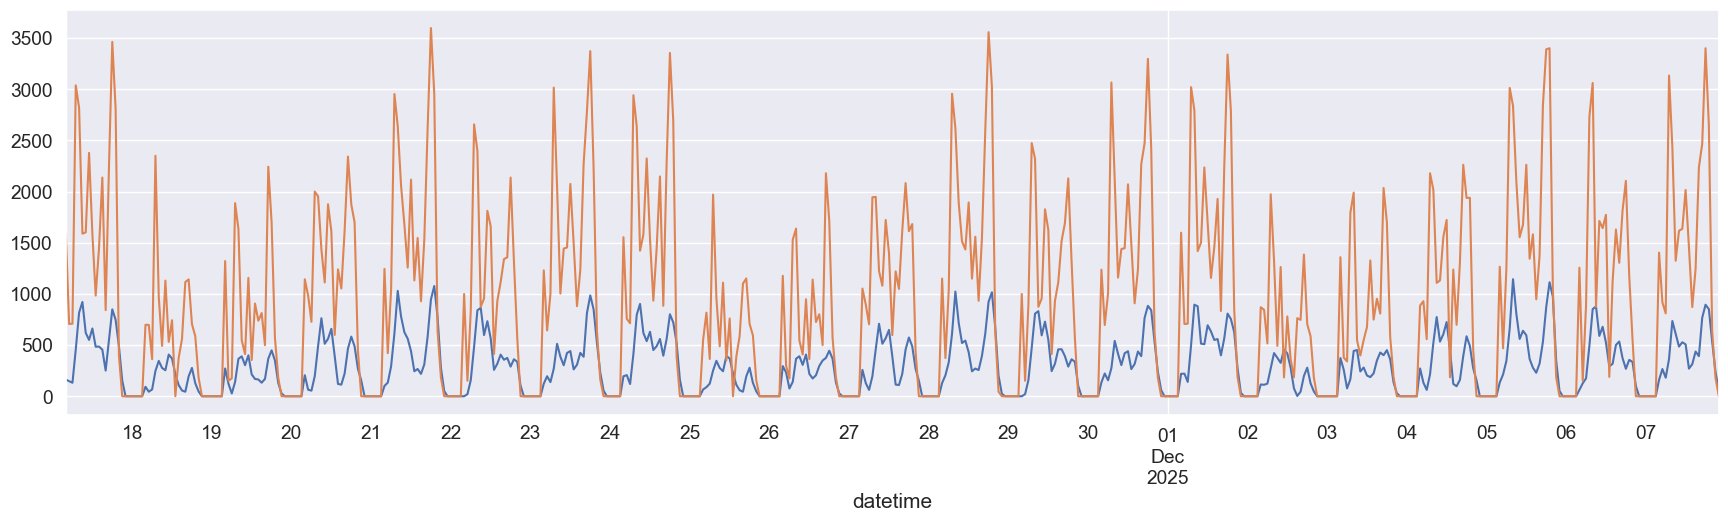

In [52]:
fig, ax = plt.subplots(figsize=(19, 5))
df_mod['real_pax_passport'].plot(ax=ax, label='y')
df_mod['tot_pax'].plot(ax=ax, label='variable exógena')

<Axes: xlabel='datetime'>

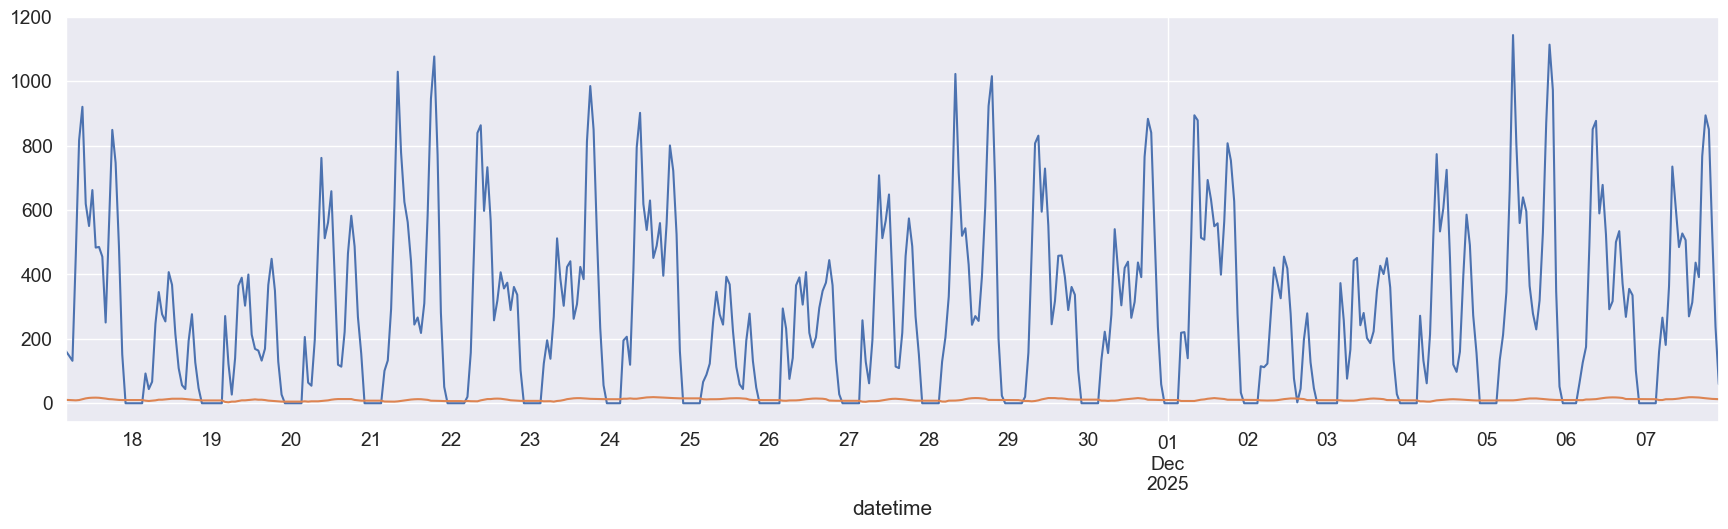

In [53]:
fig, ax = plt.subplots(figsize=(19, 5))
df_mod['real_pax_passport'].plot(ax=ax, label='y')
df_mod['temperatura'].plot(ax=ax, label='variable exógena')

<Axes: xlabel='datetime'>

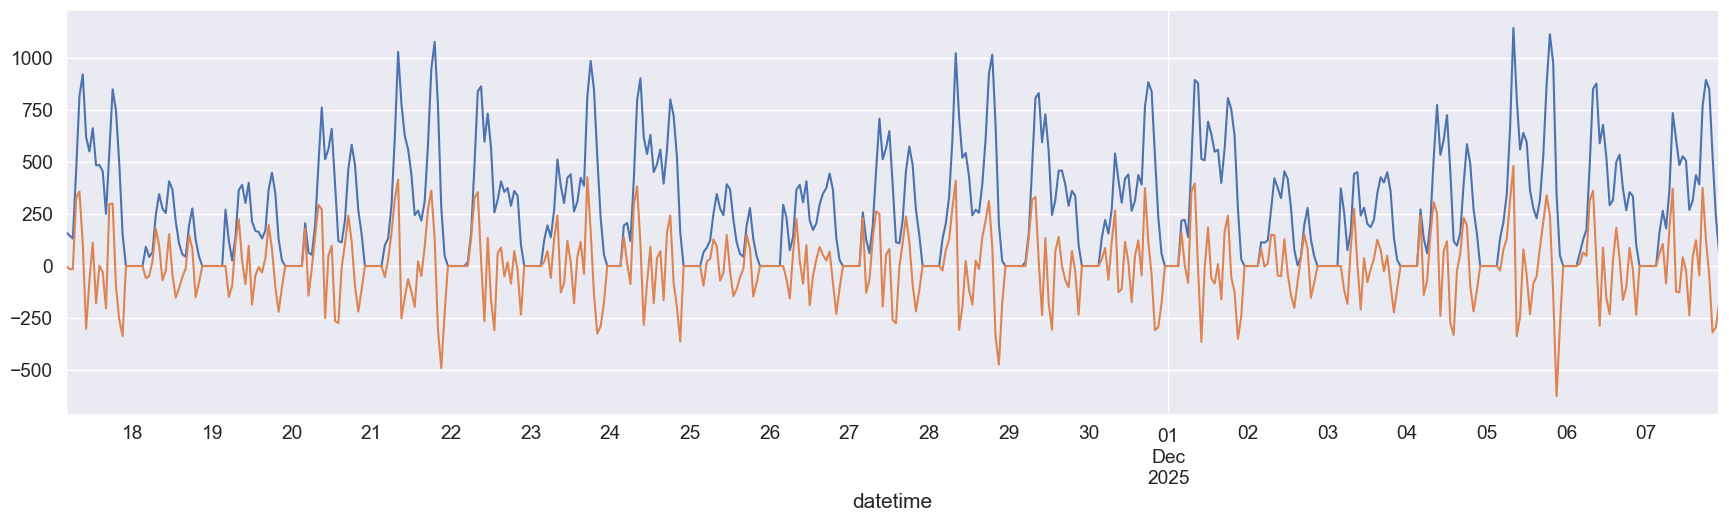

In [54]:
fig, ax = plt.subplots(figsize=(19, 5))
df_mod['real_pax_passport'].plot(ax=ax, label='y')
df_mod['pax_momentum_pas'].plot(ax=ax, label='variable exógena')

In [55]:
exogena =['pax_momentum_pas','festivo','no_vuelos','Visp_fest',
         'temperatura','v_viento','weekday_num',
          'is_morning','is_evening','is_night']
# estado_clima, 'active_flt_2h' mucha correlacion casi del 90 y pico 
#'Group_Ryanair', 'tot_pax','no_vuelos',
#'EU_flt','NAC_flt','INT_flt', 'INT_flt','Delayed_flt','Ontime_flt',

In [56]:
forecaster = ForecasterRecursive(
    regressor = RandomForestRegressor(
        n_estimators=90,
        max_depth=4,
        min_samples_split=6, # numero minimo de muestras dividir 
        min_samples_leaf=4, 
        max_features=0.5,
        random_state=123),
    lags = [1,3, 6, 8, 12, 24])

# VARIABLES EXOGENAS 
#features = [col for col in df_mod.columns if col != "real_pax_checkin_adj"]

forecaster.fit(
    y = datos_train["real_pax_passport"],
    exog = datos_train[exogena]
)

forecaster

=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  3  6  8 12 24] 
Window features: None 
Window size: 24 
Exogenous included: True 
Exogenous names: 
    pax_momentum_pas, festivo, no_vuelos, Visp_fest, temperatura, v_viento,
    weekday_num, is_morning, is_evening, is_night 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2025-11-17 04:00:00'), Timestamp('2025-12-06 08:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: h 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    4, 'max_features': 0.5, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 4, 'min_samples_split': 6,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 90,
    'n_jobs': None, 'oob_score': False, 'random_state': 123, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2026-02-04 15:25:52 
Last fit date: 2026-02-04 15:25:52 
Skforecast version: 0.14.0 
Python version: 3.10.19 
Forecaster id: None

In [57]:
steps = 38 #predice los próximos 36 valores futuros de tu serie
predicciones = forecaster.predict(steps=steps, exog = datos_test[exogena])

In [58]:
impotancia = forecaster.get_feature_importances()
impotancia

,feature,importance
0,lag_1,0.441398
5,lag_24,0.234895
6,pax_momentum_pas,0.141008
15,is_night,0.060046
8,no_vuelos,0.048136
4,lag_12,0.022874
1,lag_3,0.018108
12,weekday_num,0.010107
3,lag_8,0.005667
14,is_evening,0.004937


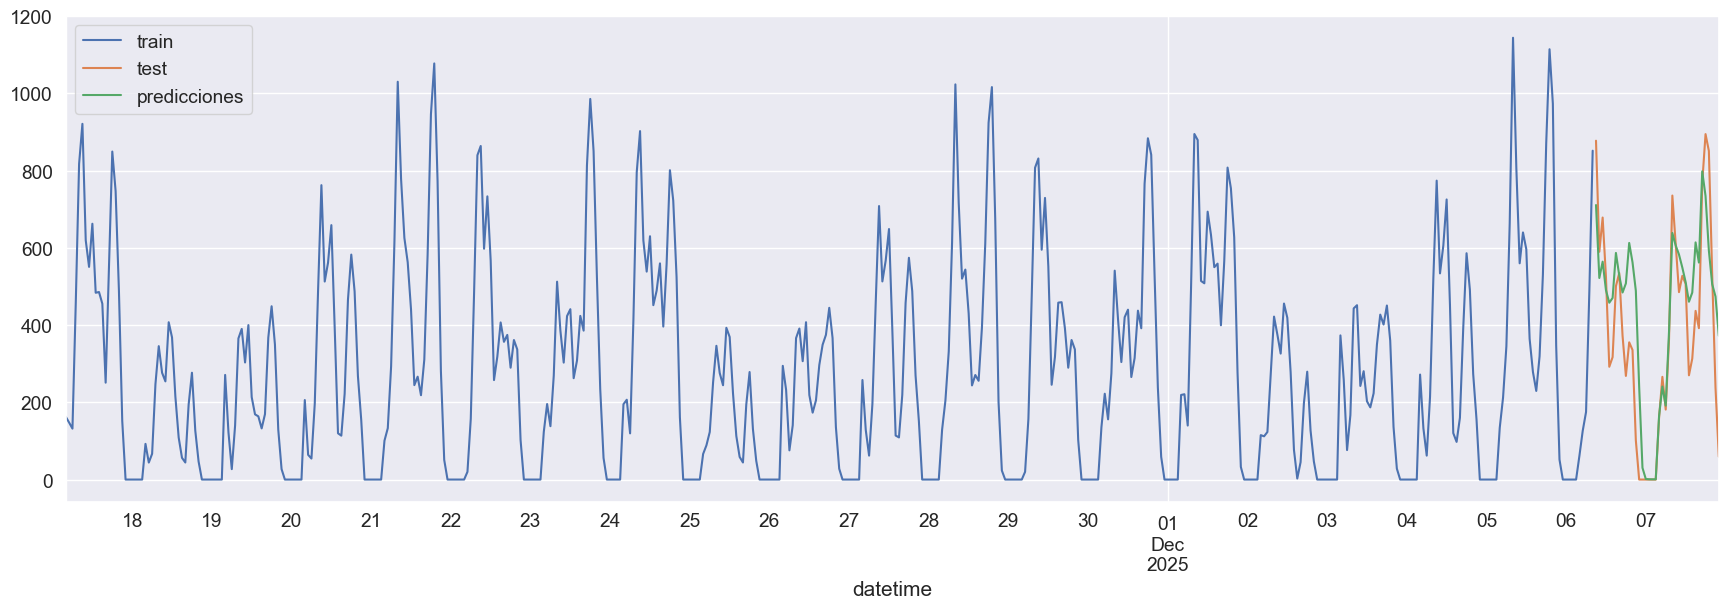

In [59]:
# Gráfico
# ==============================================================================
fig, ax = plt.subplots(figsize=(19, 6))
datos_train['real_pax_passport'].plot(ax=ax, label='train')
datos_test['real_pax_passport'].plot(ax=ax, label='test')
predicciones.plot(ax=ax, label='predicciones')
ax.legend();

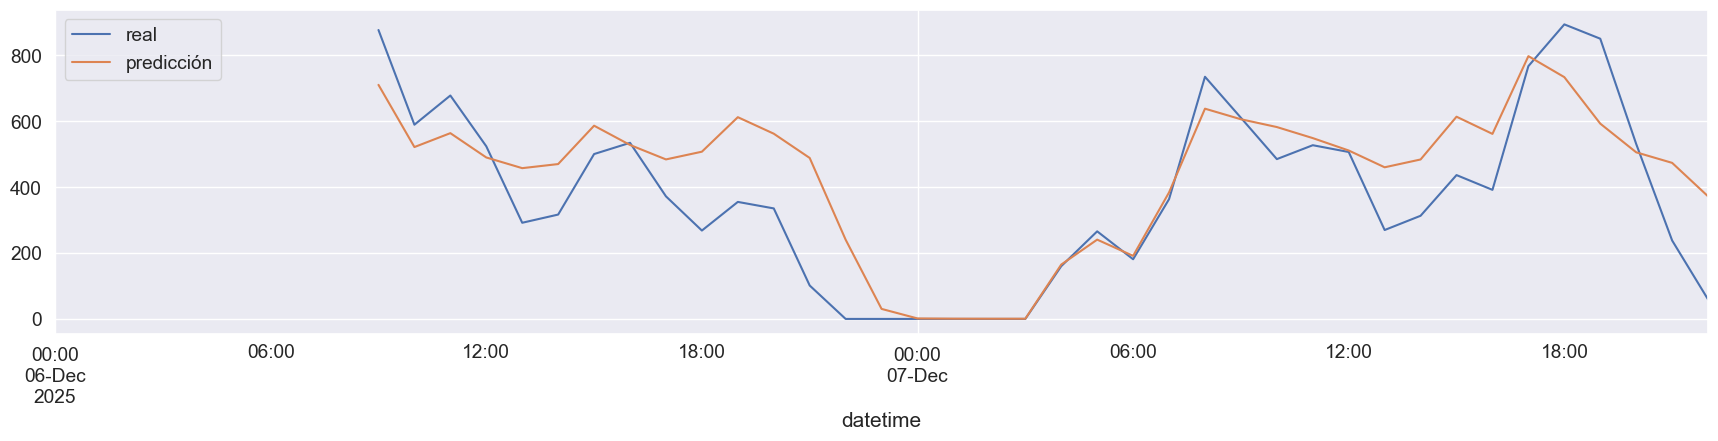

In [60]:
fig, ax = plt.subplots(figsize=(19, 4))

datos_test['real_pax_passport'].plot(ax=ax, label='real')
predicciones.plot(ax=ax, label='predicción')

ax.set_xlim(pd.Timestamp("2025-12-06"), pd.Timestamp("2025-12-07 22:00"))
ax.legend()
ax.grid(True)
plt.show()


In [61]:
# Error test
# ==============================================================================
error_mse = mean_squared_error(
                y_true = datos_test['real_pax_passport'],
                y_pred = predicciones
            )

print(f"Error de test (mse): {error_mse}")

Error de test (mse): 23554.523936845675


In [62]:
# Error test
# ==============================================================================
error_rmse = root_mean_squared_error(
                y_true = datos_test['real_pax_passport'],
                y_pred = predicciones
            )

print(f"Error de test (rmse): {error_rmse}")

# 104.59034436020629 error promedio en la unidad original (pax)
# se equicox en la prediccion de afluencia por hora en un promedio de 148 personas
# promedio de personas es 356.25 con una rmse de 82-> error es 43%
# 96.10


Error de test (rmse): 153.47483160715856


In [63]:
# Error test
# ==============================================================================
error_r2 = r2_score(
                y_true = datos_test['real_pax_passport'],
                y_pred = predicciones
            )

print(f"Error de test (r2): {error_r2}")

# 0.9731405079192047 
# explica el 94% 
# 95%
# 0,79% 
# 0.80%

Error de test (r2): 0.6479044807406273


In [64]:
"""
# 1. Obtener las predicciones sobre el mismo conjunto de entrenamiento
# Nota: La documentación de skforecast indica que este método no requiere 'exog'
# si 'exog' fue usado durante el entrenamiento.
predicciones_train = forecaster.get_train_predict() 

# 2. Calcular el error (ya no hay problema de dimensiones)
error_mset = mean_squared_error(
    y_true = datos_train['real_pax_checkin_adj'],
    y_pred = predicciones_train
)

print(f"Error de entrenamiento (mse): {error_mset}"
"""

'\n# 1. Obtener las predicciones sobre el mismo conjunto de entrenamiento\n# Nota: La documentación de skforecast indica que este método no requiere \'exog\'\n# si \'exog\' fue usado durante el entrenamiento.\npredicciones_train = forecaster.get_train_predict() \n\n# 2. Calcular el error (ya no hay problema de dimensiones)\nerror_mset = mean_squared_error(\n    y_true = datos_train[\'real_pax_checkin_adj\'],\n    y_pred = predicciones_train\n)\n\nprint(f"Error de entrenamiento (mse): {error_mset}"\n'

In [65]:
from skforecast.model_selection import backtesting_forecaster
"""
initial_train_size_value = int(len(datos_train) * 0.7)

metric, predictions = backtesting_forecaster(
    forecaster       = forecaster,
    y                = datos_train["real_pax_checkin_adj"],
    exog             = datos_train[exogena],
    initial_train_size = initial_train_size_value,
    steps            = 36,
    metric           = 'mean_absolute_error'
)
"""

'\ninitial_train_size_value = int(len(datos_train) * 0.7)\n\nmetric, predictions = backtesting_forecaster(\n    forecaster       = forecaster,\n    y                = datos_train["real_pax_checkin_adj"],\n    exog             = datos_train[exogena],\n    initial_train_size = initial_train_size_value,\n    steps            = 36,\n    metric           = \'mean_absolute_error\'\n)\n'

In [66]:
# Grid search de hiperparámetros
# ==============================================================================
forecaster = ForecasterRecursive(
                 regressor = RandomForestRegressor(random_state=123),
                 lags      = 12 # This value will be replaced in the grid search
             )
#hiperparametrizacion con el cross validacion 
# Training and validation folds
cv = TimeSeriesFold(
      steps              = 38,
      initial_train_size = int(len(datos_train) * 0.5),
      refit              = False,
      fixed_train_size   = False,

    )

# Candidate values for lags
lags_grid = [2, 20]

# Candidate values for regressor's hyperparameters
param_grid = {
    'n_estimators': [40,50,60,70,80],
    'max_depth': [6,7,9,10, 11],
    'min_samples_split':[5,6,7,8],
    'min_samples_leaf':[3,4,5]
}

resultados_grid = grid_search_forecaster(
                    forecaster  = forecaster,
                    y           = datos_train['real_pax_passport'],
                    exog        = datos_train[exogena],
                    cv          = cv,
                    param_grid  = param_grid,
                    lags_grid   = lags_grid,
                    metric      = 'mean_squared_error',  
                    return_best = True,
                    n_jobs      = 'auto',
                    verbose     = False
                )

lags grid: 100%|██████████████████████████| 2/2 [04:25<00:00, 132.57s/it]


`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20] 
  Parameters: {'max_depth': 11, 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 70}
  Backtesting metric: 6408.462472328287


In [67]:
resultados_grid

,lags,lags_label,params,mean_squared_error,max_depth,min_samples_leaf,min_samples_split,n_estimators
0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 11, 'min_samples_leaf': 3, 'min_...",6408.462472,11,3,6,70
1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 11, 'min_samples_leaf': 3, 'min_...",6408.462472,11,3,5,70
2,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 10, 'min_samples_leaf': 3, 'min_...",6408.462472,10,3,6,70
3,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 10, 'min_samples_leaf': 3, 'min_...",6408.462472,10,3,5,70
4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 9, 'min_samples_leaf': 3, 'min_s...",6408.611492,9,3,6,70
...,...,...,...,...,...,...,...,...
595,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 7, 'min_samples_leaf': 5, 'min_s...",10222.652623,7,5,5,60
596,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 6, 'min_samples_leaf': 5, 'min_s...",10522.785900,6,5,7,60
597,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 6, 'min_samples_leaf': 5, 'min_s...",10522.785900,6,5,8,60
598,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 6, 'min_samples_leaf': 5, 'min_s...",10522.785900,6,5,5,60


In [69]:
# Crear y entrenar forecaster con mejores hiperparámetros
# ==============================================================================

regressor = RandomForestRegressor(n_estimators=70, 
                                  max_depth=11, 
                                  min_samples_split=6, # numero minimo de muestras dividir 
                                  min_samples_leaf=3, 
                                  #max_features=0.5, 
                                  random_state=123)

forecaster = ForecasterRecursive(
                 regressor = regressor,
                 lags      = 20,
             )
#forecaster.fit(y=datos_train['real_pax_seguridad'])
forecaster.fit(y=datos_train['real_pax_passport'], exog = datos_train[exogena])


In [70]:
# Predicciones
# ==============================================================================
predicciones = forecaster.predict(steps=steps, exog = datos_test[exogena])
predicciones.head(5)

2025-12-06 09:00:00    809.010877
2025-12-06 10:00:00    596.807035
2025-12-06 11:00:00    648.944040
2025-12-06 12:00:00    486.153784
2025-12-06 13:00:00    253.804380
Freq: h, Name: pred, dtype: float64

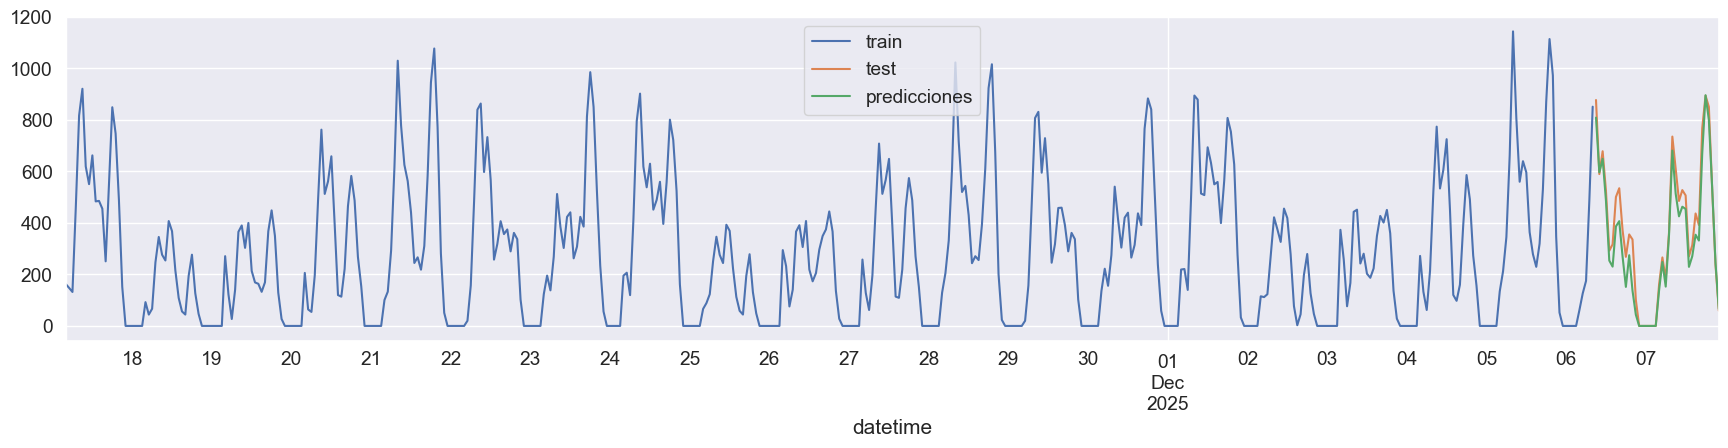

In [71]:
# Gráfico
# ==============================================================================
fig, ax = plt.subplots(figsize=(19, 4))
datos_train['real_pax_passport'].plot(ax=ax, label='train')
datos_test['real_pax_passport'].plot(ax=ax, label='test')
predicciones.plot(ax=ax, label='predicciones')
ax.legend();

In [72]:
# Error de test
# ==============================================================================
error_mse = mean_squared_error(
                y_true = datos_test['real_pax_passport'],
                y_pred = predicciones
            )

print(f"Error de test (mse) {error_mse}")

Error de test (mse) 4470.035861784204


In [73]:
# Error test
# ==============================================================================
error_rmse = root_mean_squared_error(
                y_true = datos_test['real_pax_passport'],
                y_pred = predicciones
            )

print(f"Error de test (rmse): {error_rmse}")

Error de test (rmse): 66.85832679467984


In [74]:
# Error test
# ==============================================================================
error_r2 = r2_score(
                y_true = datos_test['real_pax_passport'],
                y_pred = predicciones
            )

print(f"Error de test (r2): {error_r2}")

# 0.9731405079192047 
# 

Error de test (r2): 0.9331814303662936


Test zoom: (38, 24)
Pred zoom: (38,)


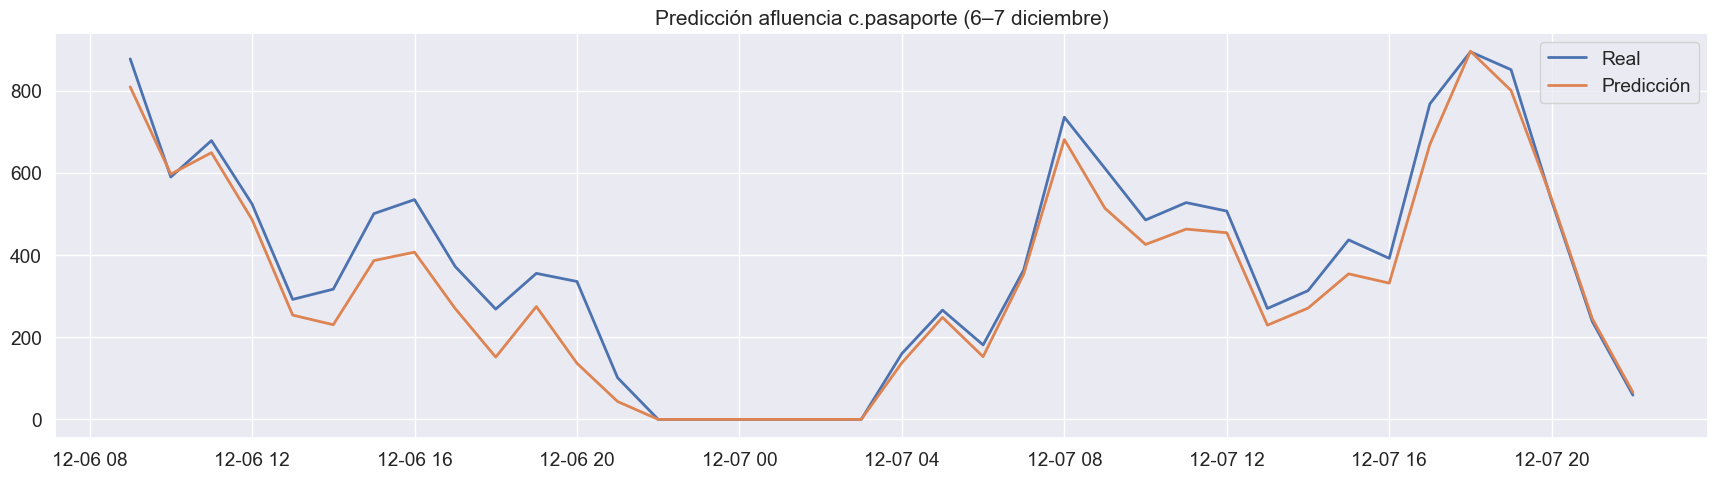

In [75]:
predicciones.index = pd.to_datetime(predicciones.index)
datos_test.index   = pd.to_datetime(datos_test.index)


inicio = pd.Timestamp("2025-12-06 09:00")
fin    = pd.Timestamp("2025-12-07 22:00")

test_zoom = datos_test.loc[inicio:fin]
pred_zoom = predicciones.loc[inicio:fin]

print("Test zoom:", test_zoom.shape)
print("Pred zoom:", pred_zoom.shape)

fig, ax = plt.subplots(figsize=(19, 5))

if len(test_zoom) > 0:
    ax.plot(test_zoom.index, 
            test_zoom['real_pax_passport'], 
            label="Real", 
            linewidth=2)

if len(pred_zoom) > 0:
    ax.plot(pred_zoom.index, 
            pred_zoom.values, 
            label="Predicción", 
            linewidth=2)

ax.set_title("Predicción afluencia c.pasaporte (6–7 diciembre)")
ax.legend()
ax.grid(True)
plt.show()


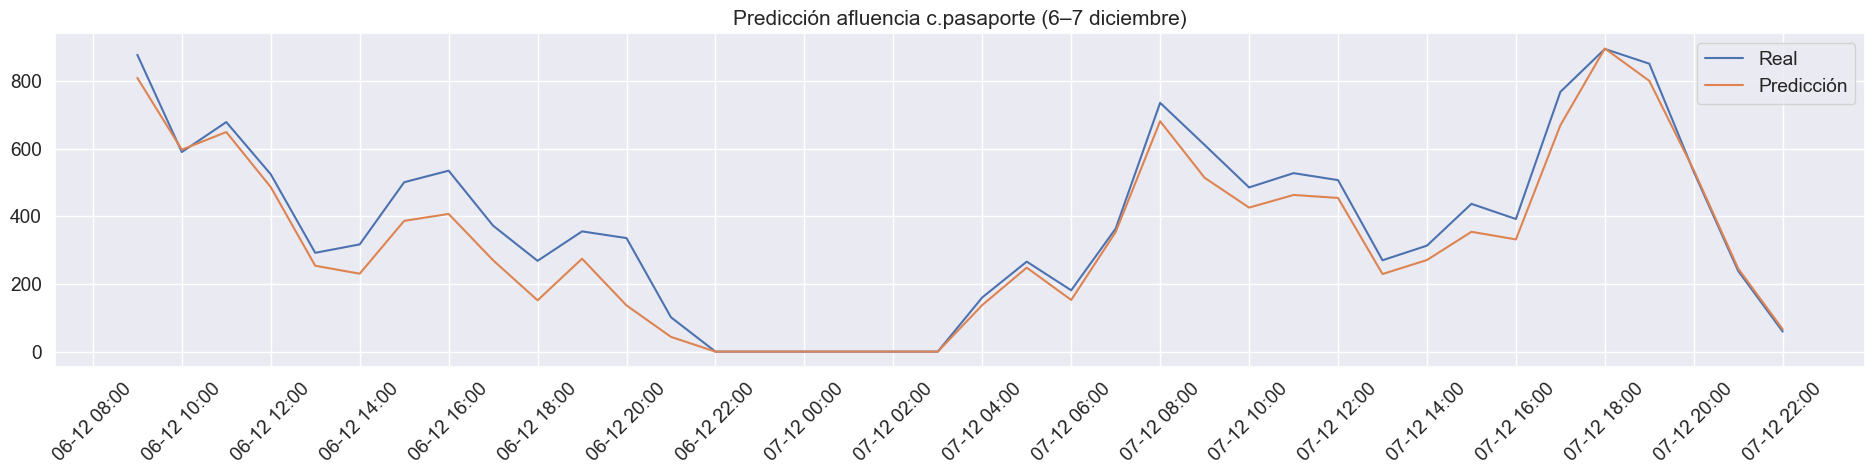

In [76]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(19, 5))

ax.plot(test_zoom.index, test_zoom['real_pax_passport'], label="Real")
ax.plot(pred_zoom.index, pred_zoom.values, label="Predicción")

ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))

ax.set_title("Predicción afluencia c.pasaporte (6–7 diciembre)")
ax.legend()
ax.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [77]:
df_eval = test_zoom.copy()
df_eval["pred"] = pred_zoom.values
df_eval["error"] = df_eval["real_pax_passport"] - df_eval["pred"]
df_eval["abs_error"] = df_eval["error"].abs()
df_eval["hora"] = df_eval.index.hour


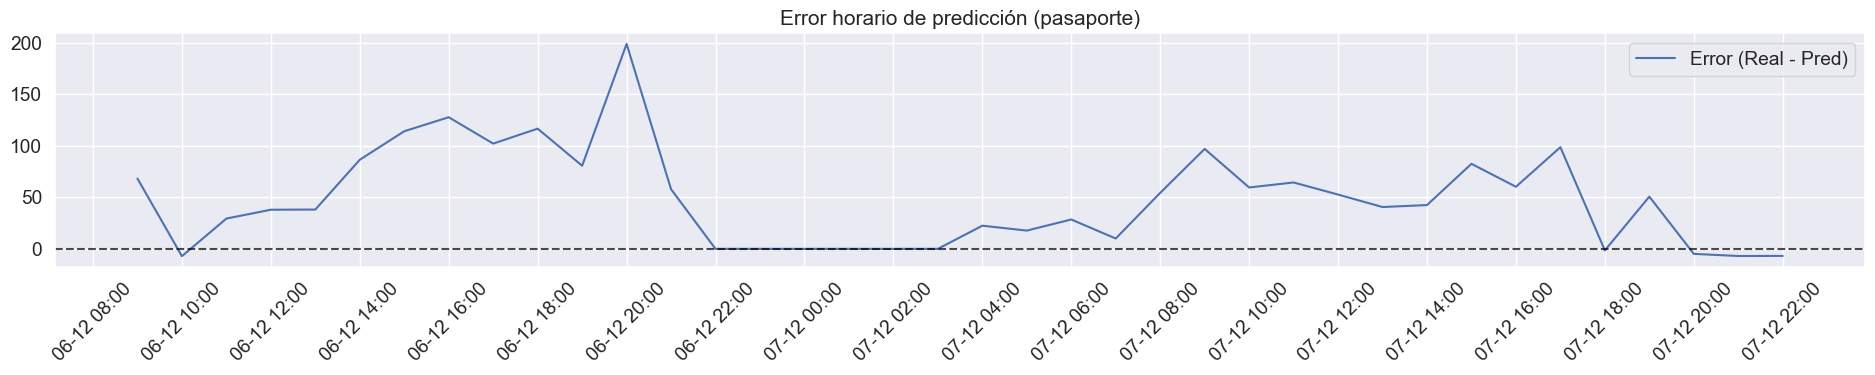

In [85]:
fig, ax = plt.subplots(figsize=(19, 4))

ax.plot(df_eval.index, df_eval["error"], label="Error (Real - Pred)")
ax.axhline(0, color="black", linestyle="--", alpha=0.7)

ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))

ax.set_title("Error horario de predicción (pasaporte)")
ax.legend()
ax.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Error positivo** → infraestima (llega más gente de lo previsto) a las 16:00/06:00/09:00/18:00 estimo que llega x cantidad de pax, pero la realidad es que hay más. 

**Error negativo** → sobreestima  (llega menos gente de lo previsto) a las 10:00 estimo que hay x pasajeros pero en realidad hay menos. 


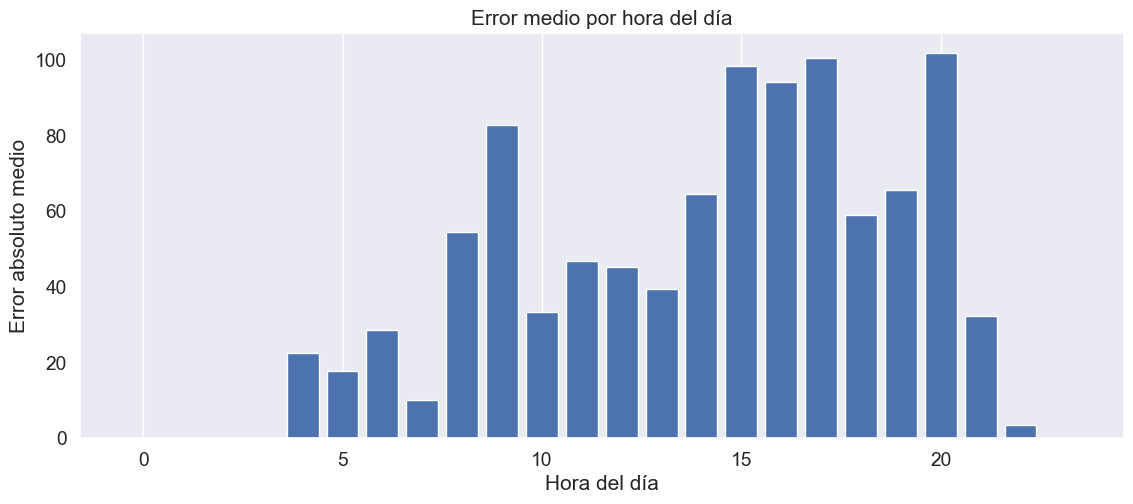

In [79]:
error_por_hora = (
    df_eval
    .groupby("hora")["abs_error"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.bar(error_por_hora["hora"], error_por_hora["abs_error"])
plt.xlabel("Hora del día")
plt.ylabel("Error absoluto medio")
plt.title("Error medio por hora del día")
plt.grid(axis="y")
plt.show()


In [80]:
error_por_hora.sort_values("abs_error", ascending=False).head(5)


,hora,abs_error
20,20,101.922025
17,17,100.474114
15,15,98.409630
16,16,94.063427
9,9,82.656171


EL MODELO DE AFLUENCIA EN EL CONTROL DE PASAPORTES PREDICE PEOR EN LAS HORAS:
- Por las mañanas: 9
- Por las tardes: 20, 17,15, 16

In [81]:
df_eval[df_eval["hora"] == 00][
    ["real_pax_passport", "pred", "new_pax_passport", "is_night","is_morning",'is_evening','temperatura', 'v_viento', 'weekday_num']
].head()


,real_pax_passport,pred,new_pax_passport,is_night,is_morning,is_evening,temperatura,v_viento,weekday_num
datetime,,,,,,,,,
2025-12-07,0.0,0.0,0.0,1,0,0,12.5,11.1,6


In [86]:
"""
['new_pax_passport','festivo',
         'temperatura','v_viento','weekday',
          'is_morning','is_evening','is_night']
"""

"\n['new_pax_passport','festivo',\n         'temperatura','v_viento','weekday',\n          'is_morning','is_evening','is_night']\n"

In [87]:
forecaster_f = ForecasterRecursive(
                 regressor = regressor,
                 lags      = 20,
             )
forecaster_f.fit(y=df_mod['real_pax_passport'], exog = df_mod[exogena])

In [88]:
# Guardar modelo
save_forecaster(forecaster_f, file_name='forecasterPAS_DIC.joblib', verbose=False)

In [89]:
df_mod['real_pax_passport'].describe() # 32 bajo, 250 medio, 455 alto

count     499.000000
mean      291.115763
std       269.139041
min         0.000000
25%        27.525000
50%       250.854878
75%       458.293598
max      1143.859146
Name: real_pax_passport, dtype: float64

In [90]:
df_pred = pd.DataFrame({
    'datetime': predicciones.index,
    'pred_checkin': predicciones.values
})
df_pred

,datetime,pred_checkin
0,2025-12-06 09:00:00,809.010877
1,2025-12-06 10:00:00,596.807035
2,2025-12-06 11:00:00,648.944040
3,2025-12-06 12:00:00,486.153784
4,2025-12-06 13:00:00,253.804380
5,2025-12-06 14:00:00,230.305138
6,2025-12-06 15:00:00,386.408575
7,2025-12-06 16:00:00,406.907270
8,2025-12-06 17:00:00,269.946771
9,2025-12-06 18:00:00,151.591840


In [91]:
df_pred.shape

(38, 2)

In [92]:
df_pred['pred_checkin'].mean()

np.float64(329.5177545350196)

In [93]:
df_pred['pred_checkin'].describe()

count     38.000000
mean     329.517755
std      250.810415
min        0.000000
25%      141.127441
50%      272.637682
75%      480.360006
max      895.837936
Name: pred_checkin, dtype: float64

In [94]:
df_pred['datetime'].unique()

<DatetimeArray>
['2025-12-06 09:00:00', '2025-12-06 10:00:00', '2025-12-06 11:00:00',
 '2025-12-06 12:00:00', '2025-12-06 13:00:00', '2025-12-06 14:00:00',
 '2025-12-06 15:00:00', '2025-12-06 16:00:00', '2025-12-06 17:00:00',
 '2025-12-06 18:00:00', '2025-12-06 19:00:00', '2025-12-06 20:00:00',
 '2025-12-06 21:00:00', '2025-12-06 22:00:00', '2025-12-06 23:00:00',
 '2025-12-07 00:00:00', '2025-12-07 01:00:00', '2025-12-07 02:00:00',
 '2025-12-07 03:00:00', '2025-12-07 04:00:00', '2025-12-07 05:00:00',
 '2025-12-07 06:00:00', '2025-12-07 07:00:00', '2025-12-07 08:00:00',
 '2025-12-07 09:00:00', '2025-12-07 10:00:00', '2025-12-07 11:00:00',
 '2025-12-07 12:00:00', '2025-12-07 13:00:00', '2025-12-07 14:00:00',
 '2025-12-07 15:00:00', '2025-12-07 16:00:00', '2025-12-07 17:00:00',
 '2025-12-07 18:00:00', '2025-12-07 19:00:00', '2025-12-07 20:00:00',
 '2025-12-07 21:00:00', '2025-12-07 22:00:00']
Length: 38, dtype: datetime64[ns]

In [95]:
df_pred["hora"] = df_pred["datetime"].dt.hour
df_pred["fecha"] = df_pred["datetime"].dt.date
df_pred["weekday"] = df_pred["datetime"].dt.weekday


In [ ]:
#df_pred.to_csv("Tabla_aflu_pasport.csv") 